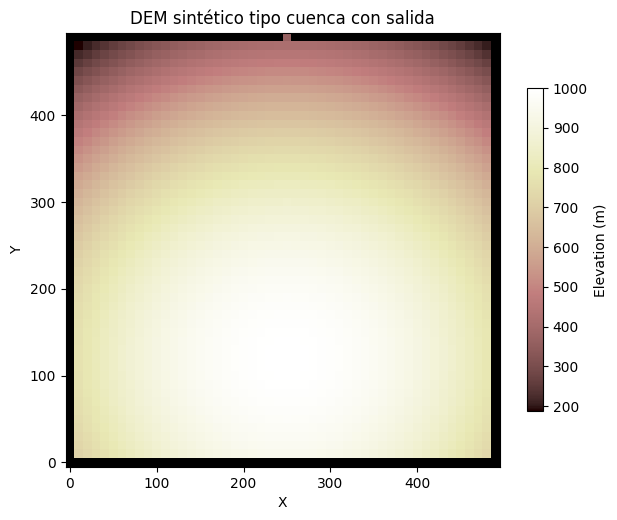

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab.plot import imshow_grid

# Parámetros del modelo
nrows, ncols = 50, 50
dx = 10.0

# Crear grilla
mg = RasterModelGrid((nrows, ncols), xy_spacing=dx)

# Crear elevación tipo huevo
yc, xc = nrows // 4, ncols // 2
yy, xx = np.meshgrid(np.arange(nrows), np.arange(ncols), indexing="ij")
cuenca = 0.5 * ((xx - xc) / (ncols / 2))**2 + ((yy - yc) / (nrows / 1.5))**2
elev = 1000 - cuenca * 500

# Hacer una salida clara
elev[-1, ncols // 2] -= 20

# Agregar campo a Landlab
mg.add_field("topographic__elevation", elev.ravel(), at="node", units="m")

# Condiciones de borde
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_row = nrows - 1  # última fila (borde inferior)
outlet_col = ncols // 2  # centro horizontal
outlet_node = outlet_row * ncols + outlet_col
# Condiciones de borde
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)

# Definir nodo de salida (parte inferior centro)
outlet_row = nrows - 1
outlet_col = ncols // 2
outlet_node = outlet_row * ncols + outlet_col
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE


# Mostrar el modelo
plt.figure(figsize=(7, 6))
imshow_grid(mg, "topographic__elevation", colorbar_label="Elevation (m)", shrink=0.7)
plt.title("DEM sintético tipo cuenca con salida")
plt.show()


